In [3]:
import csv

# Convert raw tab-separated file to CSV
with open("data/raw_data/data.txt") as fin, open("data/raw_data/data.csv", "w", newline="") as fout:
    reader = csv.reader(fin, delimiter="\t")
    writer = csv.writer(fout)
    writer.writerow(["collected_at", "line", "transport_mode", "planned_time", "estimated_time"])
    writer.writerows(reader)

print("Converted data.txt → data/raw_data/data.csv")


FileNotFoundError: [Errno 2] No such file or directory: 'data/raw_data/data.txt'

In [4]:
import pandas as pd

# ── Direction lookup: (line, HH:MM) → direction label ────────────────────────
DIRECTION_FILES = {
    ("data/cleaned_data/line_6__kortedala_scheduled.csv",  6):  "Kortedala via Centralstationen",
    ("data/cleaned_data/line_6_varmfront_scheduled.csv",   6):  "Länsmansgården via Sahlgrenska",
    ("data/cleaned_data/line_64_heden_scheduled.csv",      64): "Heden",
    ("data/cleaned_data/line_64_axel_scheduled.csv",       64): "Högsbohöjd",
}

lookup = {}
for (path, line_num), direction in DIRECTION_FILES.items():
    dir_df = pd.read_csv(path)
    for t in dir_df["departure_time"]:
        lookup[(line_num, str(t)[:5])] = direction

# ── Load raw data, filter lines 6 & 64 ───────────────────────────────────────
raw = pd.read_csv("data/raw_data/data.csv")
raw = raw[raw["line"].isin([6, 64])].copy()

# ── Parse times to HH:MM:SS ──────────────────────────────────────────────────
raw["planned_time"]   = pd.to_datetime(raw["planned_time"]).dt.strftime("%H:%M:%S")
raw["estimated_time"] = pd.to_datetime(raw["estimated_time"]).dt.strftime("%H:%M:%S")

# ── Assign direction via lookup on (line, HH:MM) ─────────────────────────────
raw["direction"] = raw.apply(
    lambda r: lookup.get((r["line"], r["planned_time"][:5]), "unknown"),
    axis=1
)

# ── Deduplicate: unique departure = (line, direction, planned_time), keep last ─
final = (
    raw
    .drop_duplicates(subset=["line", "direction", "planned_time"], keep="last")
    .reset_index(drop=True)
)

# ── Compute delay in minutes ──────────────────────────────────────────────────
def to_minutes(t: str) -> int:
    h, m, _ = t.split(":")
    return int(h) * 60 + int(m)

final["delay_minutes"] = (
    final["estimated_time"].apply(to_minutes) - final["planned_time"].apply(to_minutes)
)

# ── Keep only the columns we care about ──────────────────────────────────────
final = final[["line", "direction", "planned_time", "estimated_time", "delay_minutes"]]

# ── Save ──────────────────────────────────────────────────────────────────────
out = "data/cleaned_data/final_departures.csv"
final.to_csv(out, index=False)
print(f"Saved {len(final)} rows → {out}")
print(f"\nunknown direction count: {(final['direction'] == 'unknown').sum()}")
print(f"\nDirections:\n{final.groupby(['line','direction']).size().to_string()}")
final


Saved 68 rows → data/cleaned_data/final_departures.csv

unknown direction count: 1

Directions:
line  direction                     
6     Kortedala via Centralstationen    16
      Länsmansgården via Sahlgrenska    19
64    Heden                             13
      Högsbohöjd                        19
      unknown                            1


,line,direction,planned_time,estimated_time,delay_minutes
0,6,Länsmansgården via Sahlgrenska,06:31:00,06:33:00,2
1,64,Högsbohöjd,06:28:00,06:35:00,7
2,64,Heden,06:36:00,06:35:00,-1
3,6,Länsmansgården via Sahlgrenska,06:19:00,06:38:00,19
4,6,Kortedala via Centralstationen,06:35:00,06:39:00,4
...,...,...,...,...,...
63,64,Högsbohöjd,09:19:00,09:19:00,0
64,6,Kortedala via Centralstationen,09:23:00,09:24:00,1
65,64,Heden,09:25:00,09:25:00,0
66,6,Länsmansgården via Sahlgrenska,09:22:00,09:27:00,5


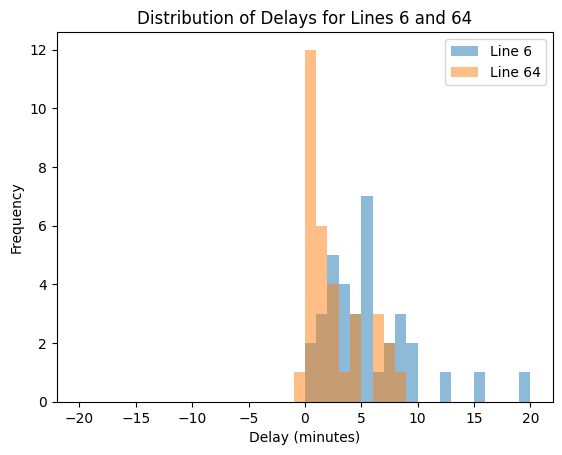

In [5]:
# histogram of delay_minutes for bus and tram separately
import matplotlib.pyplot as plt
for line in [6, 64]:
    subset = final[final["line"] == line]
    plt.hist(subset["delay_minutes"], bins=range(-20, 21), alpha=0.5, label=f"Line {line}")
plt.xlabel("Delay (minutes)")
plt.ylabel("Frequency")
plt.title("Distribution of Delays for Lines 6 and 64")
plt.legend()
plt.show()